# Ordinary Least Squares with Multiple Linear Regression



Now that we've estimated the parameters for **simple linear regression** with OLS, let's do the same for **multiple linear regression**.

## Multiple Linear Regression: Recap

Multiple linear regression generalizes simple linear regression by allowing more than one input variable: $x_1, x_2, \dots, x_d$. The goal of multiple linear regression is to find a relationship between the input variables and the output variable:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d$$

$\beta_1$ through $\beta_d$ are the estimated regression coefficients for the independent variables $x_1$ through $x_d$. As in simple linear regression, the regression model for the actual output variable is:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_d x_d + \epsilon$$

$\epsilon$ is the random error / residual — the difference between the actual output point and the predicted output point.


## Why Matrix Form?

Multiple linear regression involves more than one input variable, so it's impossible to individually derive a solution for each regression coefficient. In a real-world regression problem, the dimension $d$ (number of features) can be very large.

**So how do we estimate all regression coefficients at once?**

With $n$ observations, we can write:

$$
\begin{aligned}
y_1 &= \beta_0 + \beta_1 x_{11} + \beta_2 x_{12} + \dots + \beta_d x_{1d} + \epsilon_1 \\
y_2 &= \beta_0 + \beta_1 x_{21} + \beta_2 x_{22} + \dots + \beta_d x_{2d} + \epsilon_2 \\
y_3 &= \beta_0 + \beta_1 x_{31} + \beta_2 x_{32} + \dots + \beta_d x_{3d} + \epsilon_3 \\
&\;\vdots \\
y_n &= \beta_0 + \beta_1 x_{n1} + \beta_2 x_{n2} + \dots + \beta_d x_{nd} + \epsilon_n
\end{aligned}
$$

where $x_{nd}$ is the $n$th observation for the $d$th feature. This system can be written compactly in matrix form:

$$
\begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}
=
\begin{bmatrix} 1 & x_{11} & \cdots & x_{1d} \\ 1 & x_{21} & \cdots & x_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \cdots & x_{nd} \end{bmatrix}
\begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_d \end{bmatrix}
+
\begin{bmatrix} \epsilon_1 \\ \epsilon_2 \\ \vdots \\ \epsilon_n \end{bmatrix}
$$

Using matrix notation:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \epsilon \quad \dots (1)$$

- $\mathbf{y}$ is an $n \times 1$ column matrix of observed outputs.
- $\mathbf{X}$ is an $n \times (d+1)$ matrix. The extra column of 1's accounts for the intercept $\beta_0$.
- There are $(d+1)$ unknown parameters — $d$ coefficients plus 1 intercept — so $\boldsymbol{\beta}$ is a $(d+1) \times 1$ column matrix.



## Deriving the Normal Equation

From OLS, our objective is to find the column vector $\boldsymbol{\beta}$ that **minimizes the Sum of Squared Errors (SSE)**.

$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} \epsilon_i^2$$

Since $\epsilon = \begin{bmatrix} \epsilon_1 \\ \epsilon_2 \\ \vdots \\ \epsilon_n \end{bmatrix}$, we have $\epsilon^T \epsilon = \epsilon_1^2 + \epsilon_2^2 + \dots + \epsilon_n^2 = \sum_{i=1}^n \epsilon_i^2 = SSE$.

From equation (1): $\epsilon = \mathbf{y} - \mathbf{X}\boldsymbol{\beta}$, so:

$$SSE = \epsilon^T \epsilon = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

This is a convex quadratic function (a bowl-shaped surface), just like in simple linear regression. To minimize it, we take the derivative with respect to $\boldsymbol{\beta}$ and set it to zero:

$$\frac{\partial SSE}{\partial \boldsymbol{\beta}} = \frac{\partial}{\partial \boldsymbol{\beta}} \left( \mathbf{y}^T\mathbf{y} + \boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} \boldsymbol{\beta} - 2\boldsymbol{\beta}^T \mathbf{X}^T \mathbf{y} \right) = 0$$

Differentiating:

$$2\boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} - 2\mathbf{X}^T \mathbf{y} = 0$$

$$2\boldsymbol{\beta}^T \mathbf{X}^T \mathbf{X} = 2\mathbf{X}^T \mathbf{y}$$

Cancelling the 2's and isolating $\boldsymbol{\beta}$, we arrive at the **Normal Equation**:

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Since these are *estimated* parameters, we typically write it with a hat:

$$\boxed{\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}}$$

This is the closed-form solution for multiple linear regression using OLS..

## Implementation on Real World Dataset

We'll use the classic **Advertising** dataset (from *An Introduction to Statistical Learning*). It has three input features — **TV**, **radio**, and **newspaper** advertising spend — and one output variable, **sales**.

This is a sales-prediction problem: how does investment in each advertising medium relate to sales?

**Multiple** **Linear** **Regression**

In [ ]:
5x + 4y +3z = 20
9x +7y + 8z = 30
8x - 3y + 8z = 25 .....
[5 4 3
 9 7 8
 8 -3 8]

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

In [3]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col = 0)

In [4]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


### Visualize Each Feature vs. Sales

<Figure size 1500x400 with 0 Axes>

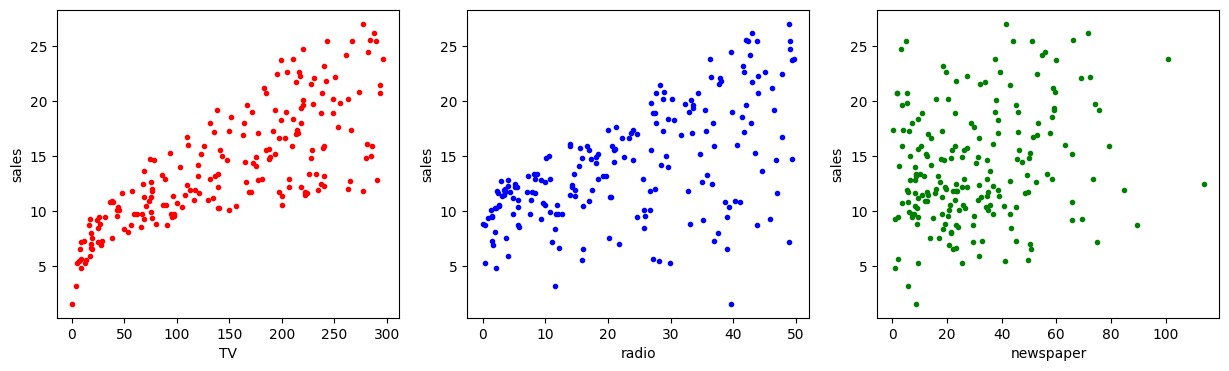

In [5]:

fig = plt.figure(figsize = (15, 4))
gs = mpl.gridspec.GridSpec(1,3,) # row * column



fig = plt.figure(figsize = (15, 4))
gs = mpl.gridspec.GridSpec(1,3,) # row * column
#plot of sales vs TV
ax =fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color = "red", marker = ".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")
# plot of sales vs radio

ax =fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color = "blue", marker = ".")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

# plot of sales vs newspaper
ax =fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color = "green", marker = ".")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")
plt.show()

**Observation:** The first plot shows a sharp upward trend in sales as TV advertising increases. A similar (though noisier) trend appears for radio. However, in the last plot, there doesn't appear to be a clear relationship between newspaper advertising and sales.

## Multiple Linear Regression using Ordinary Least Squares

Earlier in simple linear regression, we used one input variable at a time. Now, with multiple linear regression, we use more than one input variable. We'll look at two cases:

1. Combined effect of **TV** and **radio** on **sales**
2. Combined effect of **TV**, **radio**, and **newspaper** on **sales**

We'll solve both using the normal equation derived above: $\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$

In [6]:
from IPython.display import display, Math
X = data_df[["TV","radio","newspaper" ]]
y = data_df[["sales"]]

In [7]:
X = np.c_[np.ones((200,1)), X] # set bias term to 1 for each 200 samples
X

array([[  1. , 230.1,  37.8,  69.2],
       [  1. ,  44.5,  39.3,  45.1],
       [  1. ,  17.2,  45.9,  69.3],
       [  1. , 151.5,  41.3,  58.5],
       [  1. , 180.8,  10.8,  58.4],
       [  1. ,   8.7,  48.9,  75. ],
       [  1. ,  57.5,  32.8,  23.5],
       [  1. , 120.2,  19.6,  11.6],
       [  1. ,   8.6,   2.1,   1. ],
       [  1. , 199.8,   2.6,  21.2],
       [  1. ,  66.1,   5.8,  24.2],
       [  1. , 214.7,  24. ,   4. ],
       [  1. ,  23.8,  35.1,  65.9],
       [  1. ,  97.5,   7.6,   7.2],
       [  1. , 204.1,  32.9,  46. ],
       [  1. , 195.4,  47.7,  52.9],
       [  1. ,  67.8,  36.6, 114. ],
       [  1. , 281.4,  39.6,  55.8],
       [  1. ,  69.2,  20.5,  18.3],
       [  1. , 147.3,  23.9,  19.1],
       [  1. , 218.4,  27.7,  53.4],
       [  1. , 237.4,   5.1,  23.5],
       [  1. ,  13.2,  15.9,  49.6],
       [  1. , 228.3,  16.9,  26.2],
       [  1. ,  62.3,  12.6,  18.3],
       [  1. , 262.9,   3.5,  19.5],
       [  1. , 142.9,  29.3,  12.6],
 

In [8]:
X_transpose = np.transpose(X)
X_transpose

array([[  1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
          1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,   1. ,
      

In [9]:
X_transpose.shape

(4, 200)

In [10]:
# ordinary least squares
betas = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)

In [11]:
betas

array([[ 2.93888937e+00],
       [ 4.57646455e-02],
       [ 1.88530017e-01],
       [-1.03749304e-03]])

In [12]:
display(Math(r"\mathf{TV,\Radio,\ and \Newspaper}"))
display(Math(
    rf"y = {betas[0,0]: .2f} {betas[1,0]:+.2f}x_1 {betas[2,0]:+.2f}x_2 {betas[3,0]:+.2f}x_3"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Performance** **matrix**

In [13]:
# sklearn implementation
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [14]:
X = data_df[["TV", "radio", "newspaper"]].to_numpy()
Y = data_df[["sales"]].to_numpy()

In [15]:
scaler = StandardScaler()
scaler_x = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.2, random_state = 909)

In [17]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

LinearRegression()

In [18]:
linear_reg.coef_

array([[ 0.04597127,  0.19178046, -0.00600036]])

In [19]:
linear_reg.intercept_

array([2.99231988])

In [20]:
y_pred = linear_reg.predict(X_test)

In [21]:
r2_score(y_test, y_pred)

0.928413953303882

In [24]:
from IPython.display import HTML, display

In [25]:
# Training Linear Regression using TV and Radio features
X = data_df[["TV", "radio"]]
y = data_df[["sales"]]

# set bias/intercept term to 1 for each sample
n_samples = X.shape[0]
X = np.c_[np.ones((n_samples, 1)), X]
X_transpose = np.transpose(X)

# implementing least square solution of matrix form
betas_tv_radio = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)

message = """<strong>TV and Radio</strong> <br>
$y$ = {:.2f} + {:.2f}$x_{{1}}$ + {:.2f}$x_{{2}}$ <br>
$x_{{1}}$ = TV <br>
$x_{{2}}$ = radio
""".format(*betas_tv_radio[0], *betas_tv_radio[1], *betas_tv_radio[2])
display(HTML(message))
print("")

In [26]:
# Training Linear Regression using all features
X = data_df[["TV", "radio", "newspaper"]]
y = data_df[["sales"]]

# set bias/intercept term to 1 for each sample
n_samples = X.shape[0]
X = np.c_[np.ones((n_samples, 1)), X]
X_transpose = np.transpose(X)

# implementing least square solution of matrix form
betas_all = np.linalg.inv(X_transpose.dot(X)).dot(X_transpose).dot(y)

message = """<strong>TV, Radio, and Newspaper</strong> <br>
$y$ = {:.2f} + {:.2f}$x_{{1}}$ + {:.2f}$x_{{2}}$ + {:.2f}$x_{{3}}$ <br>
$x_{{1}}$ = TV <br>
$x_{{2}}$ = radio <br>
$x_{{3}}$ = newspaper
""".format(*betas_all[0], *betas_all[1], *betas_all[2], *betas_all[3])
display(HTML(message))

### Interpreting the Results

**TV, radio vs. sales:**

We obtain the model $y = 2.92 + 0.05x_1 + 0.19x_2$. The intercept $\beta_0$ is estimated as $2.92$, and the two regression coefficients $\beta_1$ and $\beta_2$ are estimated as $0.05$ and $0.19$ respectively. These OLS values match the values you'd get from Scikit-Learn's `LinearRegression`.

**TV, radio, newspaper vs. sales:**

We obtain the model $y = 2.94 + 0.05x_1 + 0.19x_2 + 0.00x_3$ (each parameter rounded to 2 decimal places). The intercept $\beta_0$ is estimated as $2.94$, and the three coefficients $\beta_1, \beta_2, \beta_3$ are estimated as $0.05$, $0.19$, and $0.00$ respectively. Again, these OLS values match Scikit-Learn's results.

Notice the **newspaper** coefficient is essentially zero — consistent with the scatter plot showing little relationship between newspaper spend and sales.

## Optional: Verify with Scikit-Learn

In [27]:
from sklearn.linear_model import LinearRegression

# TV and radio
X_tr = data_df[["TV", "radio"]]
y_tr = data_df["sales"]
model_tv_radio = LinearRegression().fit(X_tr, y_tr)
print("TV & Radio -> intercept:", round(model_tv_radio.intercept_, 2),
      "coefs:", np.round(model_tv_radio.coef_, 2))

# TV, radio, newspaper
X_all = data_df[["TV", "radio", "newspaper"]]
y_all = data_df["sales"]
model_all = LinearRegression().fit(X_all, y_all)
print("TV, Radio & Newspaper -> intercept:", round(model_all.intercept_, 2),
      "coefs:", np.round(model_all.coef_, 2))

TV & Radio -> intercept: 2.92 coefs: [0.05 0.19]
TV, Radio & Newspaper -> intercept: 2.94 coefs: [ 0.05  0.19 -0.  ]


## Potential Issues with Ordinary Least Squares

We derived OLS for both simple and multiple linear regression. In both cases, OLS finds the parameter estimates that minimize the SSE. However, the derivation relies on a few assumptions — violating them can create serious problems.

### 1. Existence of $(\mathbf{X}^T \mathbf{X})^{-1}$

While calculating $\hat{\boldsymbol{\beta}}$, we assume $(\mathbf{X}^T \mathbf{X})^{-1}$ exists.

**When does it fail to exist?** The inverse doesn't exist when $\mathbf{X}^T \mathbf{X}$ is **not full rank**. Since $\mathbf{X}$ has dimension $n \times (d+1)$, it needs at least $(d+1)$ linearly independent rows to be full rank.

If there's **perfect collinearity** between any two independent (input) variables, $\mathbf{X}^T \mathbf{X}$ won't be full rank, and the inverse doesn't exist. In other words: there should be correlation between the *dependent* (output) and *independent* (input) variables, but the independent variables should be independent of **each other**.

### 2. Existence of $n \gg d$

If $n < d + 1$, we can't perform least squares — infinitely many solutions exist when the number of data points is less than the number of features. We need **more observations than features**.

---

There's another parameter-estimation method, **Gradient Descent**, which addresses these limitations of OLS. That's the topic for the next chapter.

# API key